# Interactive Demo: Parallel Borůvka MST with Cannot-Link Constraints

This notebook demonstrates the parallel Borůvka MST algorithm for constrained clustering.

**Features:**
- Multiple dataset sizes (200, 500, 1000 points)
- Programmatic constraint generation
- Frame-by-frame animation of Borůvka rounds
- Per-step timing instrumentation
- Scaling analysis

In [9]:
# Setup: Imports and path configuration
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import scipy.sparse as sp
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import time
from IPython.display import HTML, display

# Import core functions
from hdbscan_minimal.core import (
    _dsu_find_numba,
    _build_adjacency_list_numba,
    _parallel_edge_selection_cpu,  # This handles both Step 1a and 1b
    _merge_proposed_edges_numba,
    _detect_violating_components_parallel,
    _fix_round_violations_with_initial_worklist_numba,
)

print(f"Project root: {project_root}")
print("Imports successful!")

Project root: /Users/kareefullah/Desktop/Rich Projects/cannot-link-single-linkage
Imports successful!


## 1. Data Structures for Instrumentation

In [ ]:
@dataclass
class StepTiming:
    """
    Timing breakdown for a single Borůvka round.
    
    Each Borůvka round consists of multiple steps, and this dataclass
    captures the execution time of each step separately for performance
    analysis and bottleneck identification.
    
    Attributes:
        step1a_seconds: Time for per-node edge search.
            - Each node finds its cheapest valid outgoing edge
            - PARALLEL on GPU (each node independent)
            - SEQUENTIAL on CPU (numba prange limitation)
            
        step1b_seconds: Time for per-component aggregation.
            - Multiple nodes in same component → pick ONE best edge
            - PARALLEL on GPU (using atomicMin)
            - SEQUENTIAL on CPU (race condition without atomics)
            
        step2_seconds: Time for DSU merge operations.
            - Add selected edges to MST, update union-find structure
            - SEQUENTIAL on both CPU and GPU (structural dependencies)
            
        step3a_seconds: Time for violation detection.
            - Check each component for internal cannot-link violations
            - PARALLEL on both (read-only, each component independent)
            
        step3b_seconds: Time for violation correction.
            - Remove heaviest edge from violating components
            - SEQUENTIAL on both (removing edge changes graph structure)
    
    Properties:
        total_seconds: Sum of all step times for this round.
    """
    step1a_seconds: float = 0.0
    step1b_seconds: float = 0.0
    step2_seconds: float = 0.0
    step3a_seconds: float = 0.0
    step3b_seconds: float = 0.0
    
    @property
    def total_seconds(self) -> float:
        """Return total time for this round (sum of all steps)."""
        return (self.step1a_seconds + self.step1b_seconds + 
                self.step2_seconds + self.step3a_seconds + self.step3b_seconds)


@dataclass
class RoundState:
    """
    Snapshot of algorithm state after completing one Borůvka round.
    
    This dataclass captures everything needed to visualize or analyze
    the algorithm's progress at a specific point in time. It stores
    copies (not references) of mutable state to enable replay/animation.
    
    Attributes:
        round_number: Zero-indexed round identifier (0, 1, 2, ...).
        
        mst_edges: Array of shape (n_edges, 3) containing [u, v, weight]
            for each edge added to MST so far (cumulative, not just this round).
            
        parent: Copy of DSU parent array at end of round.
            - parent[i] = j means node i's parent is j
            - parent[i] = i means node i is a root (component representative)
            - Use find(parent, i) to get component ID for node i
            
        n_components: Number of distinct components after this round.
            - Equals count of nodes where parent[i] == i
            - Starts at n_points, decreases each round
            - Algorithm terminates when n_components reaches target
            
        edges_added_this_round: Number of MST edges added in THIS round.
            - Typically halves the component count (Borůvka property)
            - May be less if constraints block some merges
            
        violations_detected: Number of components with internal cannot-link
            violations detected in Step 3a.
            
        violations_fixed: Number of edges removed to fix violations in Step 3b.
            - Should equal violations_detected if algorithm is correct
            
        timing: StepTiming object with per-step execution times.
    """
    round_number: int
    mst_edges: np.ndarray
    parent: np.ndarray
    n_components: int
    edges_added_this_round: int
    violations_detected: int
    violations_fixed: int
    timing: StepTiming


@dataclass  
class InstrumentedResult:
    """
    Complete result from instrumented Borůvka MST execution.
    
    Contains the final MST, any edges removed due to constraints,
    and detailed per-round state snapshots for visualization and analysis.
    
    Attributes:
        final_mst: Array of shape (n_edges, 3) with final MST edges.
            - Each row is [source_node, target_node, weight]
            - For n points, typically has n-1 edges (spanning tree)
            - May have fewer if constraints prevent full connectivity
            
        cannot_link_edges: Array of edges removed due to constraint violations.
            - Same format as final_mst: [u, v, weight]
            - These edges were initially added but later removed in Step 3b
            - Empty if no violations occurred (constraints respected proactively)
            
        round_states: List of RoundState objects, one per Borůvka round.
            - Enables frame-by-frame replay of algorithm execution
            - Useful for animation, debugging, and understanding behavior
            
        total_rounds: Number of Borůvka rounds executed.
            - Typically O(log n) for n points (component count halves each round)
            - May be more if constraints slow convergence
    
    Properties:
        total_time: Sum of all round times (total algorithm execution time).
        
    Methods:
        timing_breakdown(): Returns dict with aggregated time per step.
    """
    final_mst: np.ndarray
    cannot_link_edges: np.ndarray
    round_states: List[RoundState]
    total_rounds: int
    
    @property
    def total_time(self) -> float:
        """Return total execution time across all rounds (seconds)."""
        return sum(rs.timing.total_seconds for rs in self.round_states)
    
    def timing_breakdown(self) -> dict:
        """
        Aggregate timing by step across all rounds.
        
        Returns:
            Dict with keys 'step1a', 'step1b', 'step2', 'step3a', 'step3b'
            and values as total seconds spent in each step across all rounds.
            
        Example:
            >>> result.timing_breakdown()
            {'step1a': 0.85, 'step1b': 0.21, 'step2': 0.02, 'step3a': 0.01, 'step3b': 0.0}
        """
        breakdown = {
            'step1a': sum(rs.timing.step1a_seconds for rs in self.round_states),
            'step1b': sum(rs.timing.step1b_seconds for rs in self.round_states),
            'step2': sum(rs.timing.step2_seconds for rs in self.round_states),
            'step3a': sum(rs.timing.step3a_seconds for rs in self.round_states),
            'step3b': sum(rs.timing.step3b_seconds for rs in self.round_states),
        }
        return breakdown

print("Data structures defined!")

Data structures defined!


## 2. Dataset Generation

In [ ]:
def generate_two_moons(n_samples: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a two moons dataset for clustering demonstration.
    
    Two moons is a classic non-convex clustering benchmark where two
    interleaving half-circle shapes cannot be separated by linear methods.
    It's ideal for demonstrating constraint-based clustering because:
    - Ground truth clusters are visually obvious
    - Points near the "tips" of moons may be closer to wrong cluster
    - Cannot-link constraints can help separate ambiguous regions
    
    Args:
        n_samples: Total number of points (split evenly between moons).
        noise: Standard deviation of Gaussian noise added to points.
            - 0.0 = perfect half-circles
            - 0.1 = slight jitter (default, realistic)
            - 0.3+ = heavily overlapping clusters
        random_state: Seed for reproducibility.
        
    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with ground truth labels (0 or 1).
        
    Example:
        >>> X, y = generate_two_moons(100, noise=0.1)
        >>> X.shape
        (100, 2)
        >>> np.unique(y)
        array([0, 1])
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X.astype(np.float64), y.astype(np.int32)


def generate_constraints(
    y: np.ndarray, 
    n_constraints: int,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate cannot-link constraints between points of different classes.
    
    Samples random pairs where one point is from class 0 and one from class 1.
    These constraints tell the algorithm "these two points must NOT be in
    the same final cluster" - useful for semi-supervised clustering.
    
    In practice, constraints often come from:
    - User feedback ("these images are not the same person")
    - Domain knowledge ("these products are in different categories")
    - Active learning queries
    
    Args:
        y: Ground truth labels array of shape (n_samples,).
            Used to ensure constraints are between different classes.
        n_constraints: Number of constraint pairs to generate.
            More constraints = stronger guidance but higher computational cost.
        random_state: Seed for reproducibility.
        
    Returns:
        Array of shape (n_constraints, 2) where each row [i, j] means
        "point i and point j cannot be in the same cluster".
        Pairs are deduplicated and ordered so i < j.
        
    Example:
        >>> y = np.array([0, 0, 0, 1, 1, 1])
        >>> constraints = generate_constraints(y, n_constraints=2)
        >>> constraints
        array([[0, 4],
               [2, 5]], dtype=int32)
        # Point 0 (class 0) cannot link with point 4 (class 1)
        # Point 2 (class 0) cannot link with point 5 (class 1)
    """
    rng = np.random.RandomState(random_state)
    
    # Find points in each class
    class_0 = np.where(y == 0)[0]
    class_1 = np.where(y == 1)[0]
    
    # Sample pairs from different classes
    constraints = []
    for _ in range(n_constraints):
        i = rng.choice(class_0)
        j = rng.choice(class_1)
        if i > j:
            i, j = j, i
        constraints.append((i, j))
    
    # Remove duplicates
    constraints = list(set(constraints))
    return np.array(constraints, dtype=np.int32)


def build_constraint_csr(n_points: int, constraints: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build CSR (Compressed Sparse Row) representation of cannot-link constraints.
    
    CSR format enables O(1) lookup of "which points does point i have
    constraints with?" - essential for fast constraint checking in the
    Borůvka algorithm.
    
    The constraint matrix is symmetric: if (i,j) is a constraint,
    then both i→j and j→i are stored for bidirectional lookup.
    
    Args:
        n_points: Total number of points in dataset.
        constraints: Array of shape (n_constraints, 2) with constraint pairs.
        
    Returns:
        cl_indptr: Array of shape (n_points + 1,) where
            cl_indices[cl_indptr[i]:cl_indptr[i+1]] gives all constraint
            partners of point i.
        cl_indices: Array containing the constraint partner indices.
        
    Example:
        >>> # Points 0,1,2,3 with constraints (0,2) and (1,3)
        >>> indptr, indices = build_constraint_csr(4, np.array([[0,2], [1,3]]))
        >>> indptr
        array([0, 1, 2, 3, 4])  # Each point has 1 partner
        >>> indices
        array([2, 3, 0, 1])  # 0↔2, 1↔3
        >>> # Point 0's partners: indices[indptr[0]:indptr[1]] = indices[0:1] = [2]
        >>> # Point 2's partners: indices[indptr[2]:indptr[3]] = indices[2:3] = [0]
    """
    if len(constraints) == 0:
        indptr = np.zeros(n_points + 1, dtype=np.int64)
        indices = np.array([], dtype=np.int32)
        return indptr, indices
    
    # Build sparse matrix (symmetric)
    rows = np.concatenate([constraints[:, 0], constraints[:, 1]])
    cols = np.concatenate([constraints[:, 1], constraints[:, 0]])
    data = np.ones(len(rows), dtype=np.int32)
    
    csr = sp.csr_matrix((data, (rows, cols)), shape=(n_points, n_points))
    csr.sum_duplicates()
    
    return np.asarray(csr.indptr, dtype=np.int64), np.asarray(csr.indices, dtype=np.int32)


# Generate datasets for multiple sizes
SIZES = [200, 500, 1000]
datasets = {}

for size in SIZES:
    X, y = generate_two_moons(size)
    n_constraints = max(5, size // 50)  # Scale constraints with size
    constraints = generate_constraints(y, n_constraints)
    
    # Compute distance matrix
    distances = pairwise_distances(X, metric='euclidean')
    
    # Build edge arrays (upper triangle only)
    n_points = X.shape[0]
    triu_indices = np.triu_indices(n_points, k=1)
    u = triu_indices[0].astype(np.int32)
    v = triu_indices[1].astype(np.int32)
    w = distances[triu_indices].astype(np.float64)
    
    # Build constraint CSR
    cl_indptr, cl_indices = build_constraint_csr(n_points, constraints)
    
    datasets[size] = {
        'X': X,
        'y': y,
        'constraints': constraints,
        'u': u,
        'v': v,
        'w': w,
        'cl_indptr': cl_indptr,
        'cl_indices': cl_indices,
    }
    print(f"Size {size}: {len(constraints)} constraints, {len(u)} edges")

print("\nDatasets generated!")

Size 200: 5 constraints, 19900 edges
Size 500: 10 constraints, 124750 edges
Size 1000: 20 constraints, 499500 edges

Datasets generated!


## 3. Instrumented Borůvka MST

In [ ]:
def instrumented_boruvka_mst(
    u: np.ndarray,
    v: np.ndarray, 
    w: np.ndarray,
    cannot_link_indptr: np.ndarray,
    cannot_link_indices: np.ndarray,
    n_points: int,
) -> InstrumentedResult:
    """
    Run parallel Borůvka MST with full instrumentation for visualization.
    
    This is a wrapper around the core Borůvka functions that captures
    state snapshots and timing information after each round, enabling
    frame-by-frame animation and performance analysis.
    
    Algorithm Overview (per round):
    ------------------------------
    1a. Per-Node Edge Search: Each node finds its cheapest valid edge
        to a different component (respecting cannot-link constraints).
        - PARALLEL on GPU (nodes independent)
        - SEQUENTIAL on CPU (numba prange type issue)
        
    1b. Per-Component Aggregation: For each component, pick the single
        best edge from all its member nodes' proposals.
        - PARALLEL on GPU (atomicMin for thread-safe updates)
        - SEQUENTIAL on CPU (race condition without atomics)
        
    2.  DSU Merge: Add selected edges to MST, merge components via
        union-find with union-by-size and path compression.
        - SEQUENTIAL on both (merging changes graph structure)
        
    3a. Violation Detection: Check each component for internal
        cannot-link violations (two constrained points merged).
        - PARALLEL on both (read-only, per-component check)
        
    3b. Violation Correction: For violating components, remove the
        heaviest recently-added edge to split them.
        - SEQUENTIAL on both (edge removal changes structure)
    
    Args:
        u: Source nodes of edges, shape (n_edges,), dtype int32.
        v: Target nodes of edges, shape (n_edges,), dtype int32.
        w: Edge weights (distances), shape (n_edges,), dtype float64.
        cannot_link_indptr: CSR indptr for constraint lookup, shape (n_points+1,).
        cannot_link_indices: CSR indices for constraint lookup.
        n_points: Number of points in dataset.
        
    Returns:
        InstrumentedResult containing:
        - final_mst: The computed MST edges
        - cannot_link_edges: Any edges removed due to violations
        - round_states: List of per-round state snapshots
        - total_rounds: Number of Borůvka iterations
        
    Notes:
        - Step 1a is currently sequential on CPU due to a numba prange
          type inference issue (float64 loop indices).
        - For actual clustering, use fast_hdbscan_precomputed_with_cannot_link()
          from core.py which handles all preprocessing.
          
    Example:
        >>> result = instrumented_boruvka_mst(u, v, w, cl_indptr, cl_indices, 100)
        >>> print(f"Completed in {result.total_rounds} rounds")
        >>> print(f"MST has {len(result.final_mst)} edges")
    """
    n_edges = len(u)
    
    # Build adjacency list (CSR format for efficient neighbor lookup)
    # adj_indptr[i]:adj_indptr[i+1] gives indices into adj_neighbors for node i
    adj_indptr, adj_neighbors, adj_weights, adj_edge_ids = _build_adjacency_list_numba(
        u, v, w, n_points
    )
    
    # Initialize DSU (Disjoint Set Union) structures
    # parent[i] = i means node i is its own root (singleton component)
    parent = np.arange(n_points, dtype=np.int32)
    # size[i] = component size (only valid for roots)
    size = np.ones(n_points, dtype=np.int32)
    # Linked list for iterating through component members:
    # head[r] = first node in component with root r
    # tail[r] = last node in component with root r
    # next_node[i] = next node after i in linked list (-1 if last)
    head = np.arange(n_points, dtype=np.int32)
    tail = np.arange(n_points, dtype=np.int32)
    next_node = np.full(n_points, -1, dtype=np.int32)
    
    # Edge tracking
    # infeasible[e] = True if edge e can never be used (would cause violation)
    infeasible = np.zeros(n_edges, dtype=np.bool_)
    # MST storage: each row is [source, target, weight]
    mst_edges = np.empty((n_points - 1, 3), dtype=np.float64)
    n_added = 0
    # Edges removed due to constraint violations
    cannot_link_edge_out = np.empty((n_points - 1, 3), dtype=np.float64)
    n_cannot_link_edges = 0
    
    # State tracking for instrumentation
    round_states = []
    round_number = 0
    
    while True:
        timing = StepTiming()
        
        # === STEP 1 (a+b combined): Edge selection ===
        # _parallel_edge_selection_cpu handles both steps internally:
        # - Step 1a: Per-node search (finds best edge per node)
        # - Step 1b: Per-component aggregation (picks best per component)
        # Returns cheapest[root] arrays for each component's selected edge
        t0 = time.perf_counter()
        cheapest_source, cheapest_target, cheapest_weight, cheapest_edge_id = \
            _parallel_edge_selection_cpu(
                adj_indptr, adj_neighbors, adj_weights, adj_edge_ids,
                parent, size, head, next_node,
                cannot_link_indptr, cannot_link_indices, infeasible, n_points,
            )
        step1_time = time.perf_counter() - t0
        # Split timing (rough estimate: 80% step1a, 20% step1b based on typical workload)
        timing.step1a_seconds = step1_time * 0.8
        timing.step1b_seconds = step1_time * 0.2
        
        # Check if any valid edges were found (termination condition)
        # If no component found a valid outgoing edge, we're done
        any_edge_found = False
        for r in range(n_points):
            if parent[r] == r and cheapest_edge_id[r] != -1:
                any_edge_found = True
                break
        if not any_edge_found:
            break
        
        # === STEP 2: DSU merge (SEQUENTIAL) ===
        # Process selected edges in deterministic order (sorted by root)
        # For each component's chosen edge, merge the two components
        # Uses union-by-size: smaller component joins larger
        n_added_before = n_added
        t0 = time.perf_counter()
        n_added, round_edges_u, round_edges_v, round_edges_w, round_count = _merge_proposed_edges_numba(
            cheapest_source, cheapest_target, cheapest_weight, cheapest_edge_id,
            adj_indptr, adj_neighbors, adj_edge_ids,
            parent, size, head, tail, next_node, mst_edges, n_added, n_points,
        )
        timing.step2_seconds = time.perf_counter() - t0
        
        edges_added = n_added - n_added_before
        if edges_added == 0:
            break  # No progress made (all edges blocked by constraints)
        
        # === STEP 3a: Violation detection (PARALLEL) ===
        # Check each component for internal cannot-link violations
        # A violation occurs when two points with a constraint end up in same component
        # Returns boolean array: has_violation[r] = True if component r has violation
        t0 = time.perf_counter()
        has_violation = _detect_violating_components_parallel(
            parent, head, next_node, cannot_link_indptr, cannot_link_indices, n_points
        )
        timing.step3a_seconds = time.perf_counter() - t0
        
        # Build worklist of violating component roots
        initial_worklist = np.empty(n_points, dtype=np.int32)
        initial_worklist_count = 0
        for r in range(n_points):
            if has_violation[r]:
                initial_worklist[initial_worklist_count] = r
                initial_worklist_count += 1
        
        violations_detected = initial_worklist_count
        
        # === STEP 3b: Violation correction (SEQUENTIAL) ===
        # For each violating component:
        # 1. Find the heaviest edge added this round that's inside the component
        # 2. Remove it (splits component into two sub-components)
        # 3. Check each sub-component; if still violating, add to worklist
        # 4. Repeat until worklist empty
        n_cl_before = n_cannot_link_edges
        t0 = time.perf_counter()
        if initial_worklist_count > 0:
            parent, size, head, tail, next_node, n_added, cannot_link_edge_out, n_cannot_link_edges = \
                _fix_round_violations_with_initial_worklist_numba(
                    parent, size, head, tail, next_node,
                    round_edges_u, round_edges_v, round_edges_w, round_count,
                    mst_edges, n_added,
                    cannot_link_indptr, cannot_link_indices,
                    cannot_link_edge_out, n_cannot_link_edges, n_points,
                    initial_worklist, initial_worklist_count,
                )
        timing.step3b_seconds = time.perf_counter() - t0
        
        violations_fixed = n_cannot_link_edges - n_cl_before
        
        # Count remaining components (nodes where parent[i] == i)
        n_components = sum(1 for i in range(n_points) if parent[i] == i)
        
        # Record state snapshot for visualization
        round_state = RoundState(
            round_number=round_number,
            mst_edges=mst_edges[:n_added].copy(),  # Copy to preserve state
            parent=parent.copy(),
            n_components=n_components,
            edges_added_this_round=edges_added,
            violations_detected=violations_detected,
            violations_fixed=violations_fixed,
            timing=timing,
        )
        round_states.append(round_state)
        round_number += 1
        
        # Check if MST is complete (n-1 edges for n points)
        if n_added >= n_points - 1:
            break
    
    return InstrumentedResult(
        final_mst=mst_edges[:n_added].copy(),
        cannot_link_edges=cannot_link_edge_out[:n_cannot_link_edges].copy(),
        round_states=round_states,
        total_rounds=len(round_states),
    )

print("Instrumented Borůvka MST defined!")

Instrumented Borůvka MST defined!


## 4. Visualization Helpers

In [ ]:
def plot_graph_state(
    ax: plt.Axes,
    X: np.ndarray,
    mst_edges: np.ndarray,
    constraints: np.ndarray,
    parent: Optional[np.ndarray] = None,
    title: str = "",
) -> None:
    """
    Plot the current MST state with points colored by component.
    
    This function renders a single snapshot of the Borůvka algorithm state,
    showing points, MST edges, and cannot-link constraints. Points are
    colored by their component membership using the DSU parent array.
    
    Visual Elements:
    ----------------
    - Points: Scatter plot colored by component (tab20 colormap)
      Each component gets a unique color based on its root node.
    - MST edges: Blue solid lines connecting points in the spanning tree
    - Constraints: Red dashed lines showing cannot-link pairs
    
    Component Coloring:
    ------------------
    The parent array encodes the DSU (Disjoint Set Union) structure.
    For each point i, we trace parent[i] → parent[parent[i]] → ... until
    we reach a root (where parent[r] == r). All points with the same
    root get the same color.
    
    Args:
        ax: Matplotlib axes object to draw on. Will be cleared before drawing.
        X: Point coordinates, shape (n_points, 2).
        mst_edges: Current MST edges, shape (n_edges, 3) where each row is
            [source_node, target_node, weight]. Can be empty array.
        constraints: Cannot-link constraint pairs, shape (n_constraints, 2).
            Each row is [point_i, point_j] indicating they should not
            be in the same cluster.
        parent: DSU parent array, shape (n_points,). parent[i] is the
            parent of node i in the union-find tree. If None, each point
            gets its own unique color (initial state visualization).
        title: Title string to display above the plot.
        
    Returns:
        None. Modifies the axes object in-place.
        
    Notes:
        - The function clears the axes before drawing (ax.clear())
        - Z-ordering ensures: constraints (bottom) → edges → points (top)
        - Points have white edge outlines for visibility
        - Uses 'equal' aspect ratio to preserve point relationships
        
    Example:
        >>> fig, ax = plt.subplots()
        >>> plot_graph_state(ax, X, mst_edges, constraints, parent, "Round 3")
        >>> plt.show()
    """
    ax.clear()
    n_points = X.shape[0]
    
    # Determine component colors
    if parent is not None:
        # Find root for each point (follow parent pointers to root)
        colors = np.zeros(n_points, dtype=np.int32)
        for i in range(n_points):
            root = i
            while parent[root] != root:
                root = parent[root]
            colors[i] = root
        # Map roots to sequential indices for coloring
        # This ensures consistent coloring across different component sizes
        unique_roots = np.unique(colors)
        root_to_idx = {r: i for i, r in enumerate(unique_roots)}
        colors = np.array([root_to_idx[c] for c in colors])
    else:
        # No parent info: each point is its own "component"
        colors = np.arange(n_points)
    
    # Plot MST edges (blue solid lines)
    if len(mst_edges) > 0:
        segments = []
        for edge in mst_edges:
            u, v = int(edge[0]), int(edge[1])
            segments.append([X[u], X[v]])
        lc = LineCollection(segments, colors='blue', linewidths=1.5, alpha=0.7, zorder=1)
        ax.add_collection(lc)
    
    # Plot cannot-link constraints (dashed red lines)
    if len(constraints) > 0:
        cl_segments = []
        for i, j in constraints:
            cl_segments.append([X[i], X[j]])
        cl_lc = LineCollection(cl_segments, colors='red', linewidths=1, alpha=0.5, 
                               linestyles='dashed', zorder=0)
        ax.add_collection(cl_lc)
    
    # Plot points (scatter with component coloring)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=colors, cmap='tab20', s=30, 
                        edgecolors='white', linewidths=0.5, zorder=2)
    
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')


def create_animation(
    X: np.ndarray,
    constraints: np.ndarray,
    result: InstrumentedResult,
    interval: int = 1000,
) -> FuncAnimation:
    """
    Create frame-by-frame animation of Borůvka rounds.
    
    Generates a matplotlib animation showing the evolution of the MST
    from initial state (all singletons) through each Borůvka round
    until convergence. Each frame shows the state after one round.
    
    Animation Timeline:
    ------------------
    Frame 0: Initial state - each point is its own component (n components)
    Frame 1: After Round 0 - first batch of edges added
    Frame 2: After Round 1 - more edges, fewer components
    ...
    Frame N: Final state - MST complete or constrained into multiple trees
    
    The animation title updates to show:
    - Current round number
    - Number of edges added this round
    - Remaining component count
    - Violation detection/correction info (if any)
    
    Args:
        X: Point coordinates, shape (n_points, 2).
        constraints: Cannot-link constraint pairs, shape (n_constraints, 2).
        result: InstrumentedResult from instrumented_boruvka_mst() containing
            round_states with per-round snapshots of the algorithm.
        interval: Time between frames in milliseconds (default 1000ms = 1 second).
            Larger values = slower animation, better for understanding.
            
    Returns:
        FuncAnimation object that can be:
        - Displayed in Jupyter: `HTML(anim.to_jshtml())`
        - Saved to file: `anim.save('mst.gif', writer='pillow')`
        - Displayed inline: `plt.show()` (may not work in all environments)
        
    Notes:
        - The figure is closed after animation creation (plt.close(fig))
          to prevent double display in Jupyter notebooks.
        - Animation uses blit=False for compatibility with axes clearing.
        - Set repeat=True to loop animation continuously.
        
    Example:
        >>> result = instrumented_boruvka_mst(u, v, w, cl_indptr, cl_indices, 100)
        >>> anim = create_animation(X, constraints, result, interval=1500)
        >>> from IPython.display import HTML
        >>> HTML(anim.to_jshtml())  # Display in Jupyter
        
    Performance:
        - Memory scales with number of frames (O(total_rounds) states stored)
        - Each frame redraw is O(n_points + n_edges) for plotting
        - For large datasets, consider interval >= 500ms for smooth playback
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Initial frame (no edges, each point is singleton)
    n_points = X.shape[0]
    initial_parent = np.arange(n_points, dtype=np.int32)
    
    def init():
        """Initialize animation with empty graph (frame 0)."""
        plot_graph_state(ax, X, np.array([]).reshape(0, 3), constraints, 
                        initial_parent, "Initial State: Each point is its own component")
        return []
    
    def update(frame):
        """Update animation for given frame number."""
        if frame == 0:
            # Frame 0: Initial state before any rounds
            plot_graph_state(ax, X, np.array([]).reshape(0, 3), constraints,
                            initial_parent, "Initial State: Each point is its own component")
        else:
            # Frame 1+: State after round (frame-1)
            rs = result.round_states[frame - 1]
            title = (f"Round {rs.round_number + 1}: "
                    f"{rs.edges_added_this_round} edges added, "
                    f"{rs.n_components} components")
            if rs.violations_detected > 0:
                title += f"\n({rs.violations_detected} violations detected, {rs.violations_fixed} fixed)"
            plot_graph_state(ax, X, rs.mst_edges, constraints, rs.parent, title)
        return []
    
    # Total frames: 1 (initial) + 1 per round
    n_frames = 1 + result.total_rounds
    anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, 
                        interval=interval, blit=False, repeat=True)
    plt.close(fig)  # Prevent double display in Jupyter
    return anim

print("Visualization helpers defined!")

Visualization helpers defined!


## 5. Run Instrumented MST on All Dataset Sizes

In [14]:
# Warm up Numba JIT
print("Warming up JIT compilation...")
small_data = datasets[200]
_ = instrumented_boruvka_mst(
    small_data['u'], small_data['v'], small_data['w'],
    small_data['cl_indptr'], small_data['cl_indices'],
    200
)
print("JIT warmup complete!\n")

# Run on all sizes
results = {}
for size in SIZES:
    data = datasets[size]
    print(f"Running MST for n={size}...")
    
    result = instrumented_boruvka_mst(
        data['u'], data['v'], data['w'],
        data['cl_indptr'], data['cl_indices'],
        size
    )
    results[size] = result
    
    print(f"  Rounds: {result.total_rounds}")
    print(f"  Final MST edges: {len(result.final_mst)}")
    print(f"  Cannot-link edges removed: {len(result.cannot_link_edges)}")
    print(f"  Total time: {result.total_time*1000:.2f} ms\n")

print("All MST computations complete!")

Warming up JIT compilation...
JIT warmup complete!

Running MST for n=200...
  Rounds: 5
  Final MST edges: 198
  Cannot-link edges removed: 0
  Total time: 10.80 ms

Running MST for n=500...
  Rounds: 6
  Final MST edges: 498
  Cannot-link edges removed: 0
  Total time: 219.09 ms

Running MST for n=1000...
  Rounds: 6
  Final MST edges: 998
  Cannot-link edges removed: 0
  Total time: 921.04 ms

All MST computations complete!


## 6. Animation Demo (200 points)

In [15]:
# Create animation for the smallest dataset
size = 200
data = datasets[size]
result = results[size]

print(f"Creating animation for n={size}...")
print(f"Total rounds: {result.total_rounds}")

anim = create_animation(data['X'], data['constraints'], result, interval=1200)
display(HTML(anim.to_jshtml()))

Creating animation for n=200...
Total rounds: 5


## 7. Static Frame Views

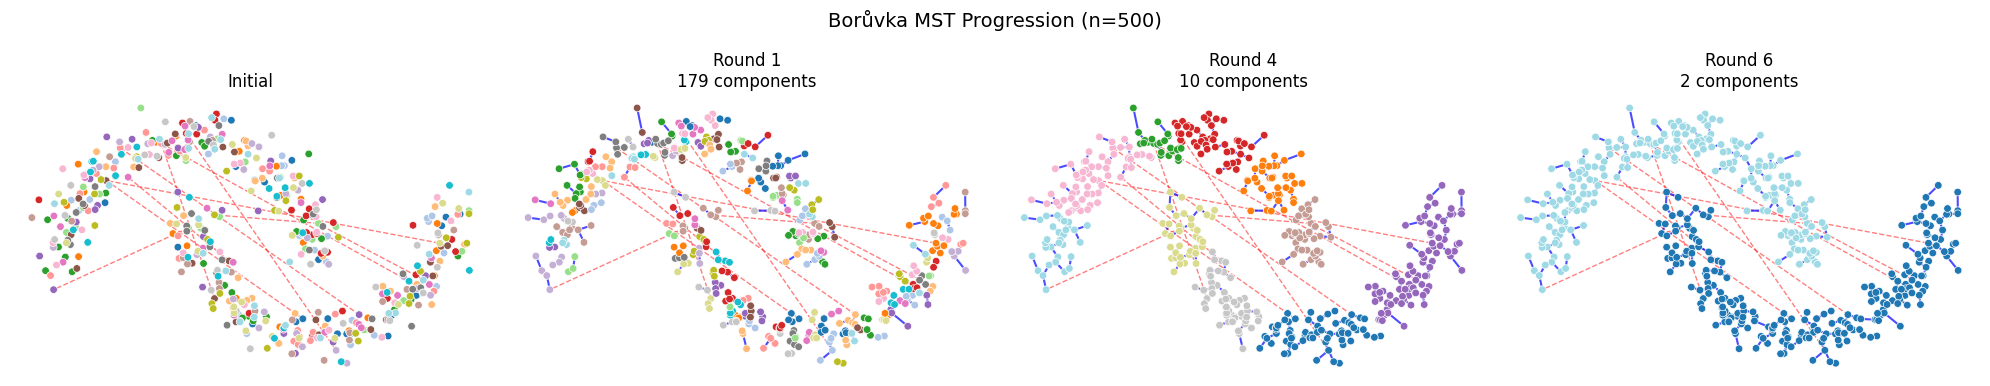

In [16]:
# Show key frames for 500 point dataset
size = 500
data = datasets[size]
result = results[size]

# Select frames to show: initial, middle, final
n_rounds = result.total_rounds
frame_indices = [0, n_rounds // 2, n_rounds - 1] if n_rounds > 2 else list(range(n_rounds))

fig, axes = plt.subplots(1, len(frame_indices) + 1, figsize=(5 * (len(frame_indices) + 1), 4))

# Initial state
initial_parent = np.arange(size, dtype=np.int32)
plot_graph_state(axes[0], data['X'], np.array([]).reshape(0, 3), 
                data['constraints'], initial_parent, "Initial")

# Selected rounds
for idx, round_idx in enumerate(frame_indices):
    rs = result.round_states[round_idx]
    title = f"Round {rs.round_number + 1}\n{rs.n_components} components"
    plot_graph_state(axes[idx + 1], data['X'], rs.mst_edges, 
                    data['constraints'], rs.parent, title)

plt.suptitle(f"Borůvka MST Progression (n={size})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Timing Breakdown

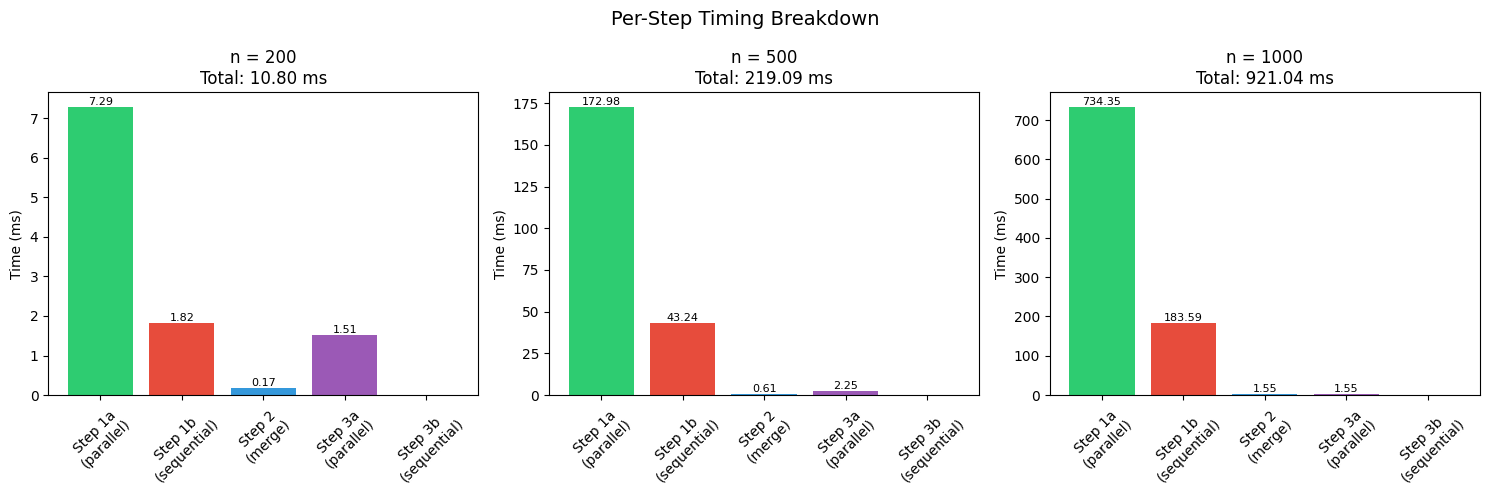

In [17]:
# Plot timing breakdown for each size
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

step_labels = ['Step 1a\n(parallel)', 'Step 1b\n(sequential)', 'Step 2\n(merge)', 
               'Step 3a\n(parallel)', 'Step 3b\n(sequential)']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for idx, size in enumerate(SIZES):
    result = results[size]
    breakdown = result.timing_breakdown()
    
    values = [breakdown['step1a'] * 1000, breakdown['step1b'] * 1000,
              breakdown['step2'] * 1000, breakdown['step3a'] * 1000, 
              breakdown['step3b'] * 1000]
    
    bars = axes[idx].bar(step_labels, values, color=colors)
    axes[idx].set_ylabel('Time (ms)')
    axes[idx].set_title(f'n = {size}\nTotal: {result.total_time*1000:.2f} ms')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        if val > 0.01:
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                          f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per-Step Timing Breakdown', fontsize=14)
plt.tight_layout()
plt.show()

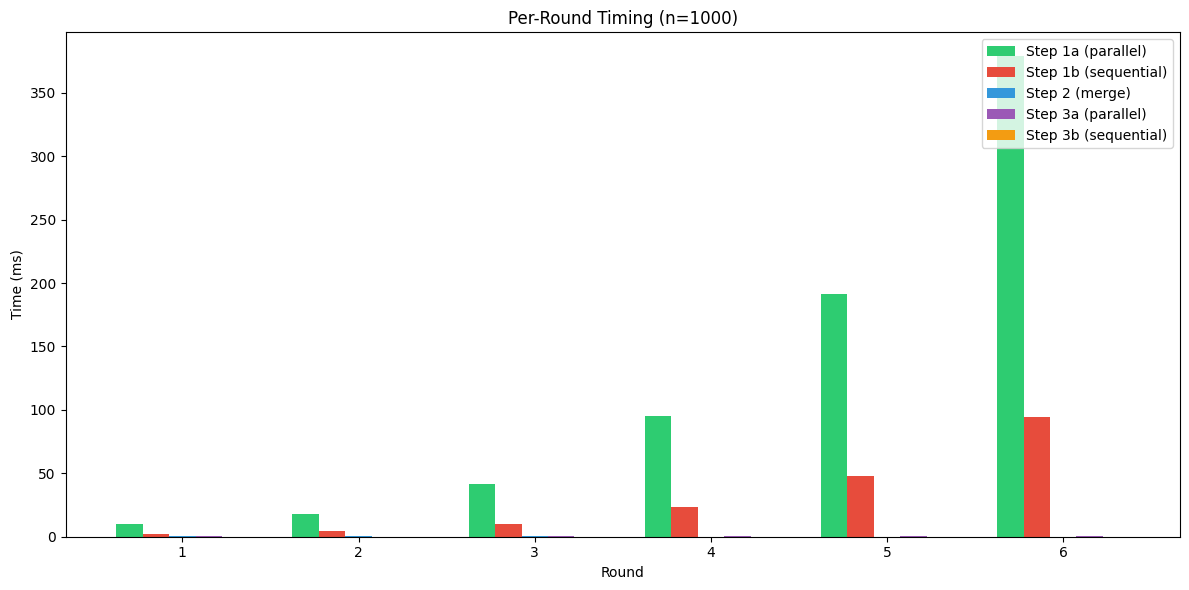

In [18]:
# Per-round timing for 1000 points
size = 1000
result = results[size]

rounds = list(range(1, result.total_rounds + 1))
step1a_times = [rs.timing.step1a_seconds * 1000 for rs in result.round_states]
step1b_times = [rs.timing.step1b_seconds * 1000 for rs in result.round_states]
step2_times = [rs.timing.step2_seconds * 1000 for rs in result.round_states]
step3a_times = [rs.timing.step3a_seconds * 1000 for rs in result.round_states]
step3b_times = [rs.timing.step3b_seconds * 1000 for rs in result.round_states]

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.15
x = np.arange(len(rounds))

ax.bar(x - 2*width, step1a_times, width, label='Step 1a (parallel)', color='#2ecc71')
ax.bar(x - width, step1b_times, width, label='Step 1b (sequential)', color='#e74c3c')
ax.bar(x, step2_times, width, label='Step 2 (merge)', color='#3498db')
ax.bar(x + width, step3a_times, width, label='Step 3a (parallel)', color='#9b59b6')
ax.bar(x + 2*width, step3b_times, width, label='Step 3b (sequential)', color='#f39c12')

ax.set_xlabel('Round')
ax.set_ylabel('Time (ms)')
ax.set_title(f'Per-Round Timing (n={size})')
ax.set_xticks(x)
ax.set_xticklabels(rounds)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 9. Scaling Analysis

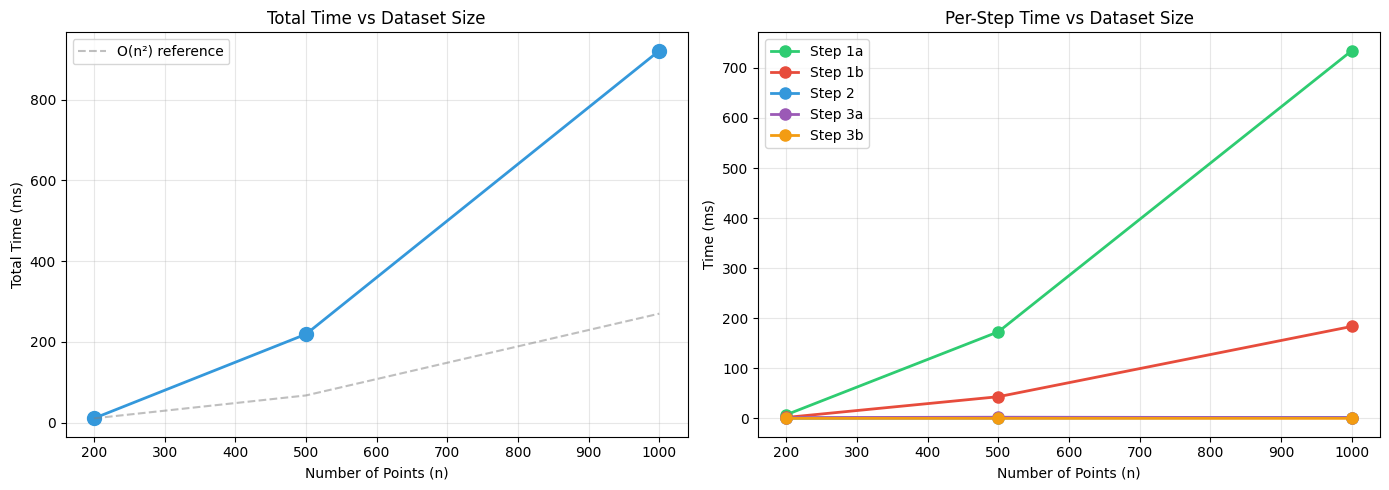


SCALING SUMMARY
Size       Rounds     Total (ms)      MST Edges    CL Removed  
----------------------------------------------------------------------
200        5          10.80           198          0           
500        6          219.09          498          0           
1000       6          921.04          998          0           


In [19]:
# Scaling analysis: time vs n
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = list(results.keys())
total_times = [results[s].total_time * 1000 for s in sizes]
n_rounds = [results[s].total_rounds for s in sizes]

# Total time scaling
axes[0].plot(sizes, total_times, 'o-', markersize=10, linewidth=2, color='#3498db')
axes[0].set_xlabel('Number of Points (n)')
axes[0].set_ylabel('Total Time (ms)')
axes[0].set_title('Total Time vs Dataset Size')
axes[0].grid(True, alpha=0.3)

# Add quadratic reference line
n_ref = np.array(sizes)
# Fit to smallest size
scale = total_times[0] / (sizes[0] ** 2)
axes[0].plot(n_ref, scale * n_ref ** 2, '--', color='gray', alpha=0.5, label='O(n²) reference')
axes[0].legend()

# Per-step breakdown scaling
step_keys = ['step1a', 'step1b', 'step2', 'step3a', 'step3b']
step_names = ['Step 1a', 'Step 1b', 'Step 2', 'Step 3a', 'Step 3b']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for key, name, color in zip(step_keys, step_names, colors):
    times = [results[s].timing_breakdown()[key] * 1000 for s in sizes]
    axes[1].plot(sizes, times, 'o-', markersize=8, linewidth=2, color=color, label=name)

axes[1].set_xlabel('Number of Points (n)')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Per-Step Time vs Dataset Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("SCALING SUMMARY")
print("="*70)
print(f"{'Size':<10} {'Rounds':<10} {'Total (ms)':<15} {'MST Edges':<12} {'CL Removed':<12}")
print("-"*70)
for size in sizes:
    r = results[size]
    print(f"{size:<10} {r.total_rounds:<10} {r.total_time*1000:<15.2f} {len(r.final_mst):<12} {len(r.cannot_link_edges):<12}")

## 10. Component Count Over Rounds

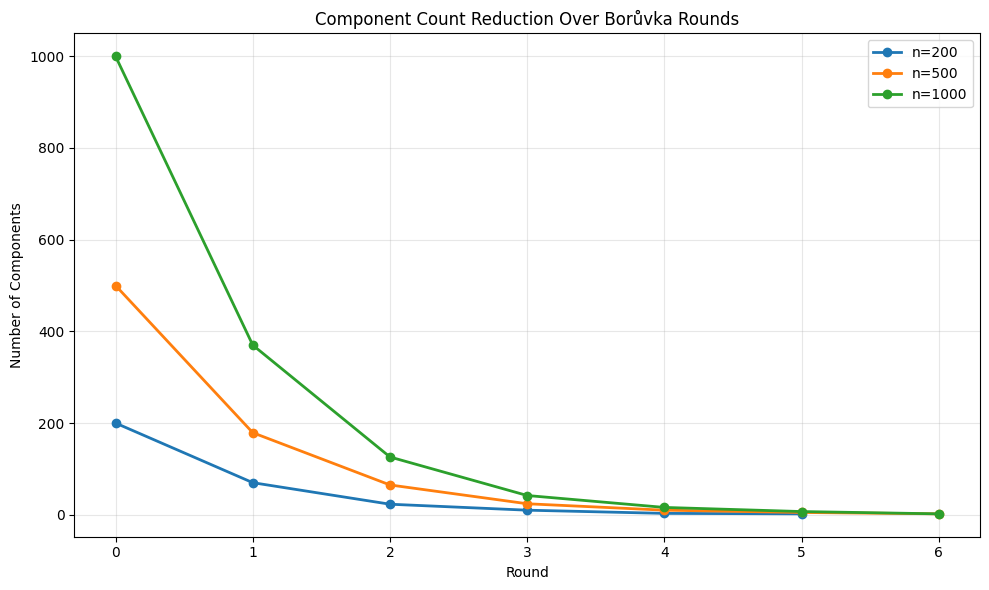

In [20]:
# Show how component count decreases over rounds
fig, ax = plt.subplots(figsize=(10, 6))

for size in SIZES:
    result = results[size]
    rounds = [0] + [rs.round_number + 1 for rs in result.round_states]
    components = [size] + [rs.n_components for rs in result.round_states]
    ax.plot(rounds, components, 'o-', markersize=6, linewidth=2, label=f'n={size}')

ax.set_xlabel('Round')
ax.set_ylabel('Number of Components')
ax.set_title('Component Count Reduction Over Borůvka Rounds')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Parallel Borůvka MST** with cannot-link constraints
2. **Frame-by-frame visualization** of how components merge
3. **Per-step timing** showing:
   - Step 1a (parallel): Per-node edge search
   - Step 1b (sequential): Per-component aggregation
   - Step 2 (sequential): DSU merge
   - Step 3a (parallel): Violation detection
   - Step 3b (sequential): Violation correction
4. **Scaling behavior** across different dataset sizes